Boosting Model Accuracy: 0.7337662337662337

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.76      0.79        99
           1       0.61      0.69      0.65        55

    accuracy                           0.73       154
   macro avg       0.71      0.72      0.72       154
weighted avg       0.74      0.73      0.74       154



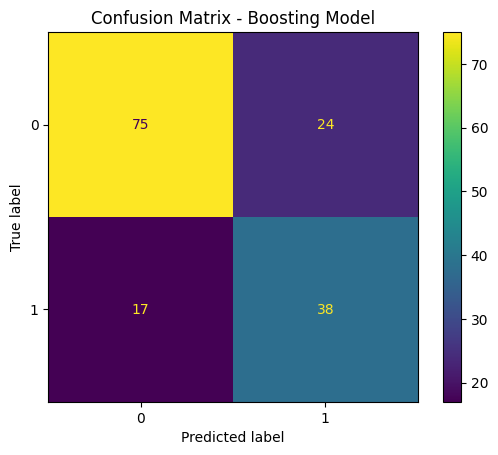

Model saved successfully!


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from pickle import dump

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Load datasets
train_data = pd.read_csv("../data/processed/clean_train.csv")
test_data = pd.read_csv("../data/processed/clean_test.csv")

# Split features and target
X_train = train_data.drop(["Outcome"], axis=1)
y_train = train_data["Outcome"]

X_test = test_data.drop(["Outcome"], axis=1)
y_test = test_data["Outcome"]

# Improved Boosting Model
model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

# Train model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print("Boosting Model Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - Boosting Model")
plt.show()

# Save model
import os
from pickle import dump

os.makedirs("../models", exist_ok=True)

dump(model, open("../models/boosting_model.sav", "wb"))

print("Model saved successfully!")